In [2]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

from utils import scorer

# Comparison of obtained models

Here we investigate the differences in prediction between the models obtained by performing validation on Tacred and on Tacrev validation sets. Results are obtained by using both models to predict relations coming from the Tacrev test set, since, according to the authors of Tacrev paper, some relationships were corrected by expert linguists and predictions can benefit by this correction.

For clarity, we are going to use the following names for referring to the obtained models:
- **tacred_results** contains predictions (on TACREV test set) obtained using the best model validated on Tacred validation set
- **tacrev_results** contains the predictions (always on TACREV test set) obtained using the best model validated on Tacrev validation set

Following the same reasoning, we name the models **TACRED model** and **TACREV model** (where the name refers to the different validation sets used during training)

In [3]:
# Read data from the text file into a DataFrame
tacred_results = pd.read_csv("./evaluation/errors_TACRED_model.txt", sep="\t")
tacrev_results = pd.read_csv("./evaluation/errors_TACREV_model.txt", sep="\t")

In [4]:
# Obtain metrics for TACRED model
summary_data = scorer.score(
    tacred_results["Gold Label"],
    tacred_results["Prediction"],
    verbose=True,
    return_data=True,
).rename(
    columns={
        "F1": "Tacred_F1",
        "Precision": "Tacred_precision",
        "Recall": "Tacred_recall",
    }
)

Per-relation statistics:
org:alternate_names                  P:  95.05%  R:  86.12%  F1:  90.36%  #: 245
org:city_of_headquarters             P:  78.95%  R:  84.27%  F1:  81.52%  #: 89
org:country_of_headquarters          P:  87.80%  R:  39.13%  F1:  54.14%  #: 92
org:dissolved                        P: 100.00%  R:   0.00%  F1:   0.00%  #: 1
org:founded                          P:  80.49%  R:  89.19%  F1:  84.62%  #: 37
org:founded_by                       P:  82.61%  R:  50.00%  F1:  62.30%  #: 76
org:member_of                        P:   0.00%  R:   0.00%  F1:   0.00%  #: 4
org:members                          P:   0.00%  R:   0.00%  F1:   0.00%  #: 16
org:number_of_employees/members      P:  91.67%  R:  78.57%  F1:  84.62%  #: 14
org:parents                          P:  42.42%  R:  24.56%  F1:  31.11%  #: 57
org:political/religious_affiliation  P:  34.78%  R:  80.00%  F1:  48.48%  #: 10
org:shareholders                     P:  16.67%  R:  33.33%  F1:  22.22%  #: 3
org:stateorprovin

In [5]:
# Obtain metrics for TACREV model
tacrev_summary_data = scorer.score(
    tacrev_results["Gold Label"],
    tacrev_results["Prediction"],
    verbose=True,
    return_data=True,
).rename(
    columns={
        "F1": "Tacrev_F1",
        "Precision": "Tacrev_precision",
        "Recall": "Tacrev_recall",
    }
)

Per-relation statistics:
org:alternate_names                  P:  95.98%  R:  87.76%  F1:  91.68%  #: 245
org:city_of_headquarters             P:  82.98%  R:  87.64%  F1:  85.25%  #: 89
org:country_of_headquarters          P:  91.43%  R:  34.78%  F1:  50.39%  #: 92
org:dissolved                        P: 100.00%  R:   0.00%  F1:   0.00%  #: 1
org:founded                          P:  86.84%  R:  89.19%  F1:  88.00%  #: 37
org:founded_by                       P:  80.56%  R:  38.16%  F1:  51.79%  #: 76
org:member_of                        P: 100.00%  R:   0.00%  F1:   0.00%  #: 4
org:members                          P:   0.00%  R:   0.00%  F1:   0.00%  #: 16
org:number_of_employees/members      P: 100.00%  R:  42.86%  F1:  60.00%  #: 14
org:parents                          P:  32.00%  R:  14.04%  F1:  19.51%  #: 57
org:political/religious_affiliation  P:  28.00%  R:  70.00%  F1:  40.00%  #: 10
org:shareholders                     P:   0.00%  R:   0.00%  F1:   0.00%  #: 3
org:stateorprovin

In [6]:
# Merge results to obtain a unique df
summary_data[["Tacrev_precision", "Tacrev_recall", "Tacrev_F1"]] = tacrev_summary_data[
    ["Tacrev_precision", "Tacrev_recall", "Tacrev_F1"]
]

# Add the difference in prediction score between the two models
summary_data["F1_diff(%)"] = (
    summary_data["Tacred_F1"] - summary_data["Tacrev_F1"]
) * 100
summary_data.head()

,Relation,Tacred_precision,Tacred_recall,Tacred_F1,test_counts,Tacrev_precision,Tacrev_recall,Tacrev_F1,F1_diff(%)
0,org:alternate_names,0.950450,0.861224,0.903640,245,0.959821,0.877551,0.916844,-1.320409
1,org:city_of_headquarters,0.789474,0.842697,0.815217,89,0.829787,0.876404,0.852459,-3.724163
2,org:country_of_headquarters,0.878049,0.391304,0.541353,92,0.914286,0.347826,0.503937,3.741638
3,org:dissolved,1.000000,0.000000,0.000000,1,1.000000,0.000000,0.000000,0.000000
4,org:founded,0.804878,0.891892,0.846154,37,0.868421,0.891892,0.880000,-3.384615


## Check which relations have been modified
Below we try to understand which relationships in the TACRED test set have been modified by the experts and with which new relations they have been replaced. 

In [7]:
# Read test data to obtain the text of the sentences
with open("../../../data/tacred/json/test.json", "r") as file:
    tacred_data_test = json.load(file)
tacred_test = pd.json_normalize(tacred_data_test).rename(
    columns={"relation": "tacred_relation"}
)

with open("../../../data/tacrev/json/test.json", "r") as file:
    tacrev_data_test = json.load(file)
tacrev_test = pd.json_normalize(tacrev_data_test).rename(
    columns={"relation": "tacrev_relation"}
)

In [8]:
relation = pd.DataFrame(
    [
        tacred_test["tacred_relation"],
        tacrev_test["tacrev_relation"],
        tacred_test["token"],
    ]
).T
diff_relations = relation[
    relation["tacred_relation"] != relation["tacrev_relation"]
]  ## obtain sentences for which the two sets have different relations
print(
    f"Percentage of modified relations: ",
    round(len(diff_relations) / len(relation) * 100, 2),
    "%",
)

Percentage of modified relations:  6.04 %


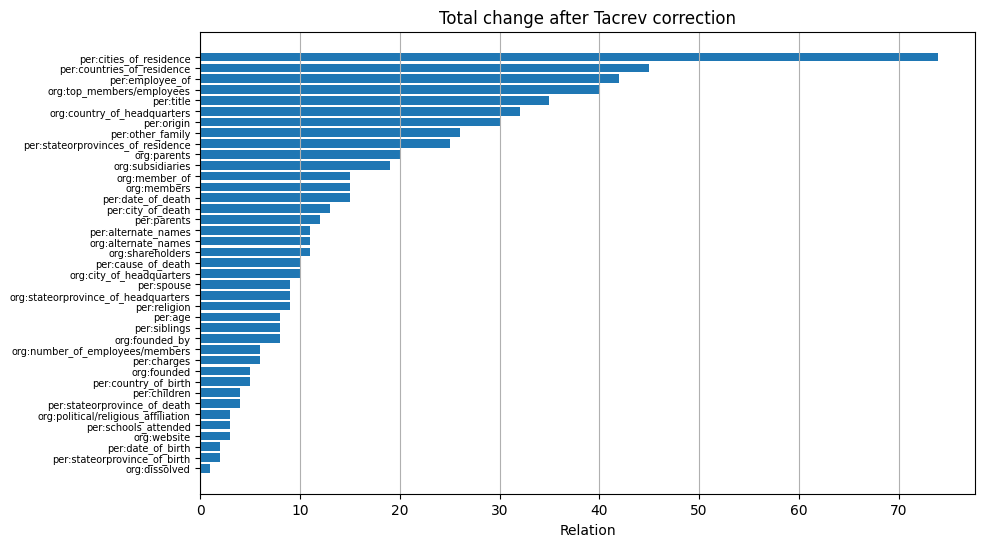

In [9]:
# Count occurrences
counts = (
    diff_relations.groupby("tacred_relation")["tacrev_relation"]
    .value_counts()
    .reset_index(name="count")
)

total_changes = (
    counts.groupby("tacred_relation")["count"].sum().reset_index(name="total_changes")
)
total_changes = total_changes[total_changes["tacred_relation"] != "no_relation"]

# Sort the DataFrame by the 'F1_diff' column
total_changes = total_changes.sort_values(by="total_changes", ascending=False)


# Plot the difference in F1 scores
plt.figure(figsize=(10, 6))
bars = plt.barh(total_changes["tacred_relation"], total_changes["total_changes"])

# Set the x-axis ticks and labels with rotation
plt.xlabel("Relation")
plt.title("Total change after Tacrev correction")
# Adjust the font size of y-axis labels
plt.yticks(fontsize=7)
plt.gca().invert_yaxis()  # Invert the y-axis to have the highest count at the top

plt.grid(axis="x")

As we can see from the plot, the relations with highest number of changes are the one related to locations (i.e., country or cities of residence), which can be sometimes misleading. Also, we have some relations which have similar meaning, but refers either to person or to organization, so it can be the case that some relations have been mislabel due to the fact that an organization is named after its owner, so it can be confused with a person's name. 

Below we investigate what are the relations that TACREV authors relabed and how. 

In [10]:
# Creating a mapping from tacred_relation to corresponding tacrev_relation and counts
relation_mapping = {}
for index, row in counts.iterrows():
    tacred_relation = row["tacred_relation"]
    tacrev_relation = row["tacrev_relation"]
    count = row["count"]

    if tacred_relation not in relation_mapping:
        relation_mapping[tacred_relation] = {}

    if tacrev_relation not in relation_mapping[tacred_relation]:
        relation_mapping[tacred_relation][tacrev_relation] = count
    else:
        relation_mapping[tacred_relation][tacrev_relation] += count

# Displaying the resulting mapping
for tacred_relation, tacrev_relations in relation_mapping.items():
    print(f"{tacred_relation}: {tacrev_relations}")

no_relation: {'per:title': 44, 'org:alternate_names': 41, 'org:top_members/employees': 38, 'per:employee_of': 29, 'per:countries_of_residence': 18, 'org:city_of_headquarters': 15, 'per:cities_of_residence': 13, 'per:siblings': 12, 'org:country_of_headquarters': 11, 'org:founded_by': 11, 'per:stateorprovinces_of_residence': 11, 'per:age': 9, 'per:charges': 9, 'per:parents': 9, 'org:stateorprovince_of_headquarters': 8, 'org:founded': 5, 'per:cause_of_death': 5, 'per:origin': 5, 'per:spouse': 5, 'org:website': 4, 'per:schools_attended': 4, 'org:political/religious_affiliation': 3, 'per:children': 3, 'per:date_of_death': 3, 'per:stateorprovince_of_death': 3, 'org:parents': 2, 'org:subsidiaries': 2, 'per:other_family': 2, 'per:religion': 2, 'org:number_of_employees/members': 1, 'per:alternate_names': 1, 'per:country_of_death': 1, 'per:stateorprovince_of_birth': 1}
org:alternate_names: {'no_relation': 9, 'org:parents': 1, 'org:subsidiaries': 1}
org:city_of_headquarters: {'no_relation': 9, 'o

It appears that in almost all cases, a relation has been changed with `no_relation` and viceversa. Also, it can bee seen how most of the relations have been relabel with relations of similar or opposite meaning, as for example `per:stateorprovince_of_birth` which is replaced once with `per:stateorprovinces_of_residence` or `org:parents` which is replaced by `org:shareholders`. 



According to TAC-KBP annotations and TACREV relabeled relations, we found groups of relations having similar meaning or inverse relations and decide to focus our attention on those. Below we report the relations and the ones with which they have been changed. 

In [11]:
considered_rel = [
    "org:city_of_headquarters",
    "org:country_of_headquarters",
    "org:stateorprovince_of_headquarters",
    "per:cities_of_residence",
    "per:city_of_birth",
    "per:city_of_death",
    "per:country_of_birth",
    "per:country_of_death",
    "per:stateorprovince_of_birth",
    "per:stateorprovince_of_death",
    "org:dissolved",
    "org_founded",
    "org:member_of",
    "org_member",
    "org:parents",
    "org:shareholders",
    "org:subsidiaries",
    "per:children",
    "per:parents",
    "per:siblings",
    "per:spouse",
    "per:other_family",
    "per:countries_of_residence",
    "per:origin",
    "per:stateorprovinces_of_residence",
]

In [12]:
considered_counts = counts[counts["tacred_relation"].isin(considered_rel)]
considered_counts.groupby("tacred_relation")["count"].sum().reset_index(
    name="total_changes"
).sort_values(by="total_changes", ascending=False)

,tacred_relation,total_changes
9,per:cities_of_residence,74
11,per:countries_of_residence,45
1,org:country_of_headquarters,32
13,per:origin,30
14,per:other_family,26
20,per:stateorprovinces_of_residence,25
4,org:parents,20
7,org:subsidiaries,19
3,org:member_of,15
10,per:city_of_death,13


We can see that, among the groups of relations that we identified, some of them have been relabeled a very high number of times by the TACREV expertes, pointing to the fact that they can be very misleading and leading to errors in prediction. 

In [13]:
# Extracting data for selected relations
filtered_dict = {k: v for k, v in relation_mapping.items() if k in considered_rel}

# Displaying the selected data
for relation, data in filtered_dict.items():
    print(f"{relation}: {data}")

org:city_of_headquarters: {'no_relation': 9, 'org:stateorprovince_of_headquarters': 1}
org:country_of_headquarters: {'no_relation': 32}
org:dissolved: {'no_relation': 1}
org:member_of: {'no_relation': 9, 'org:country_of_headquarters': 2, 'org:parents': 2, 'org:subsidiaries': 1, 'org:top_members/employees': 1}
org:parents: {'no_relation': 18, 'org:shareholders': 1, 'org:subsidiaries': 1}
org:shareholders: {'no_relation': 6, 'org:parents': 4, 'org:top_members/employees': 1}
org:stateorprovince_of_headquarters: {'no_relation': 9}
org:subsidiaries: {'no_relation': 12, 'org:parents': 6, 'org:alternate_names': 1}
per:children: {'no_relation': 2, 'per:parents': 1, 'per:spouse': 1}
per:cities_of_residence: {'no_relation': 67, 'per:stateorprovinces_of_residence': 4, 'org:city_of_headquarters': 2, 'per:countries_of_residence': 1}
per:city_of_death: {'no_relation': 11, 'per:cities_of_residence': 1, 'per:city_of_birth': 1}
per:countries_of_residence: {'no_relation': 38, 'per:origin': 4, 'org:count

## Compare TACREV model with RF
For the error analysis performed in the other notebook we focused our attention of the model obtained using TACREV validation set, since we believed that apported changes can be beneficial for the performance of the model. Below we compare results obtained using this model to the ones obtained using the RF model, on the TACREV test set. 


In [14]:
RF_results = pd.read_csv("../RF/predictions_tacrev.txt", sep="\t")
RF_summary = scorer.score(
    RF_results["Gold Label"], RF_results["Prediction"], verbose=True, return_data=True
).rename(columns={"F1": "RF_F1", "Precision": "RF_precision", "Recall": "RF_recall"})

Per-relation statistics:
org:alternate_names                  P:  78.20%  R:  67.35%  F1:  72.37%  #: 245
org:city_of_headquarters             P:  68.49%  R:  56.18%  F1:  61.73%  #: 89
org:country_of_headquarters          P:  44.29%  R:  33.70%  F1:  38.27%  #: 92
org:dissolved                        P: 100.00%  R:   0.00%  F1:   0.00%  #: 1
org:founded                          P: 100.00%  R:   0.00%  F1:   0.00%  #: 37
org:founded_by                       P: 100.00%  R:   0.00%  F1:   0.00%  #: 76
org:member_of                        P: 100.00%  R:   0.00%  F1:   0.00%  #: 4
org:members                          P: 100.00%  R:   0.00%  F1:   0.00%  #: 16
org:number_of_employees/members      P: 100.00%  R:   0.00%  F1:   0.00%  #: 14
org:parents                          P:   0.00%  R:   0.00%  F1:   0.00%  #: 57
org:political/religious_affiliation  P:  11.11%  R:  10.00%  F1:  10.53%  #: 10
org:shareholders                     P: 100.00%  R:   0.00%  F1:   0.00%  #: 3
org:stateorprovin

In [15]:
summary_data["RF_F1"] = RF_summary["RF_F1"]
summary_data["F1_LSTM-RF_F1(%)"] = abs(
    summary_data["Tacrev_F1"] - summary_data["RF_F1"]
)
summary_data = summary_data.sort_values(by="F1_LSTM-RF_F1(%)", ascending=False)

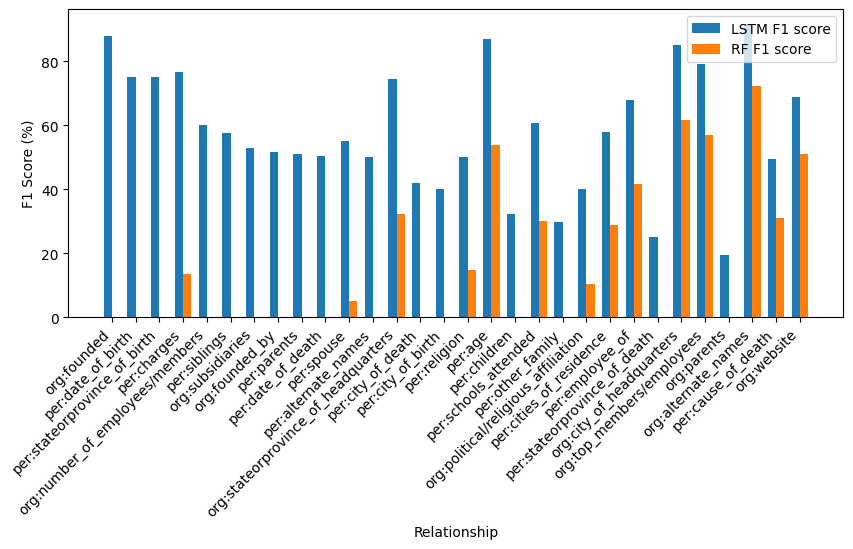

In [16]:
df = summary_data[:30]

# Bar width for each relationship
bar_width = 0.35

# Generating positions for the bars
index = np.arange(len(df["Relation"]))

plt.figure(figsize=(10, 4))
# Plotting the bar chart
plt.bar(index, df["Tacrev_F1"] * 100, bar_width, label="LSTM F1 score")
plt.bar(index + bar_width, df["RF_F1"] * 100, bar_width, label="RF F1 score")

# Adding labels and title
plt.xlabel("Relationship")
plt.ylabel("F1 Score (%)")
plt.title("")
plt.xticks(index + bar_width / 2, df["Relation"], rotation=45, ha="right")
plt.legend()

# Show the plot
plt.show()

As it can be seen from the plot, the deep learning model outperform the RF model in predicting all the relationships. However, while in some cases the difference in F1 score is not so large, see for example `org:alternate_names` or `org:city_of_headquarters`, for some others the performance of the RF are not satisfactory (see for example `per:spouse`). Furthermore, in some various cases the RF is not even able to output a relation, while the LSTM achieves very good performances (see all case in which no orange bar appears, like `org:founded`, `per:date_of_birth`,...)

These results are quite reasonable, since we are dealing with two different models in terms of complexity and training time (RF takes appriximately 5 minutes of training, while the PA-LSTM required 8 hours).